###### 31_5_real_practical_quality_data_validation_answer.ipynb

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

In [123]:
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Meiryo"

In [124]:
df_defect = pd.read_csv("dataset/lcm_quality_validation.csv")


In [125]:
trace_pattern = r"(SUS|WSE|GSE|META|MEAX|MELAC)-\d{6}-(J69P|310D|3BVT|36WA)-\d{3}"
part_pattern = r"LCM-(J69P|310D|3BVT|36WA)-\d{3}"
lot_pattern = r"LOT-\d{6}-\d{3}"
exclude_pattern = r"仮登録|TEST|参考"

In [126]:
#cell5
df_defect["trace_no_ok"] = df_defect["trace_no"].str.fullmatch(
    trace_pattern,
    na=False
)
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False


In [127]:
df_defect["part_no_ok"] = df_defect["part_no"].str.fullmatch(
    part_pattern,
    na=False,
)
df_defect.head()

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True


In [128]:
#cell7
df_defect["lot_no_ok"] = df_defect["lot_no"].str.fullmatch(
    lot_pattern,
    na=False,
)
df_defect.head()

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True


In [129]:
df_defect["exclude_keyword_flag"] = df_defect["comment"].str.contains(
    exclude_pattern,
    na=False,
regex=True,
)
df_defect.head()

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False


In [130]:
#cell9
df_defect["qty_ok"] = df_defect["defect_qty"] >= 1
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True


In [131]:
#cell10
df_defect["official_ok"] = (
    df_defect["trace_no_ok"]
    & df_defect["part_no_ok"]
    & df_defect["lot_no_ok"]
    & ~df_defect["exclude_keyword_flag"]
    & df_defect["qty_ok"]
)
df_defect.head()

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False


In [132]:
df_defect["ng_reason"] =  ""

In [133]:
df_defect.head()

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,


In [134]:
#cell 12
df_defect.loc[
    (~df_defect["trace_no_ok"])
    & (df_defect["ng_reason"] == ""),
    "ng_reason",
] = "trace_no書式NG"
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,trace_no書式NG
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,trace_no書式NG
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True,True,
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True,False,trace_no書式NG
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True,True,
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True,False,trace_no書式NG


In [135]:
df_defect.loc[
    (~df_defect["lot_no_ok"])
    & (df_defect["ng_reason"] == ""),
    "ng_reason",
] = "lot_no書式NG"
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,trace_no書式NG
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,trace_no書式NG
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True,True,
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True,False,trace_no書式NG
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True,True,
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True,False,trace_no書式NG


In [136]:
#cell 15
df_defect.loc[
    df_defect["exclude_keyword_flag"]
    & (df_defect["ng_reason"] == ""),
    "ng_reason",
] = "除外キーワードあり"
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,trace_no書式NG
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,trace_no書式NG
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True,True,
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True,False,trace_no書式NG
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True,True,
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True,False,trace_no書式NG


In [137]:
df_defect.loc[
    (~df_defect["qty_ok"])
    & (df_defect["ng_reason"] == ""),
    "ng_reason",
] = "数量0以下"
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,trace_no書式NG
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,trace_no書式NG
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True,True,
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True,False,trace_no書式NG
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True,True,
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True,False,trace_no書式NG


In [138]:
#cell 17
df_defect.loc[
    df_defect["official_ok"]
    & (df_defect["ng_reason"] == ""),
    "ng_reason",
] = "OK"
df_defect

df_defect.loc[
    (~df_defect["official_ok"])
    & (df_defect["ng_reason"] == ""),
    "ng_reason",
] = "その他確認"
df_defect

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,OK
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,OK
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,trace_no書式NG
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,OK
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,trace_no書式NG
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True,True,OK
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,OK
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True,False,trace_no書式NG
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True,True,OK
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True,False,trace_no書式NG


In [139]:
df_official = df_defect[
    df_defect["official_ok"]
].copy()
df_official

df_check = df_defect[
    ~df_defect["official_ok"]
].copy()
df_check

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,Coil,1,調査中,trace_noの区切り文字がアンダーバー,False,True,True,False,True,False,trace_no書式NG
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,Buck-IC,2,調査中,trace_noの年月形式が不正,False,True,True,False,True,False,trace_no書式NG
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,Coil,5,対策中,trace_noの連番が3桁ではない,False,True,True,False,True,False,trace_no書式NG
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,Coil,1,調査中,trace_noの機種コードが不正,False,True,True,False,True,False,trace_no書式NG
10,D011,MEAX,Honda,J69P,2026-08,MEAX-202608-J69P-011 メモあり,LCM-J69P-011,LOT-202608-011,Buck-IC,3,調査中,trace_noの末尾に余計な文字あり,False,True,True,False,True,False,trace_no書式NG
13,D014,WSE,Honda,J69P,2026-09,WSE-202609-J69P-ABC,LCM-J69P-014,LOT-202609-014,Buck-IC,1,調査中,trace_noの連番が数字ではない,False,True,True,False,True,False,trace_no書式NG
16,D017,SUS,Honda,J69P,2026-09,SUS-202609-J69P-017,LCM-J69P17,LOT-202609-017,Buck-IC,2,調査中,part_noのハイフン不足,True,False,True,False,True,False,その他確認
17,D018,WSE,Honda,310D,2026-09,WSE-202609-310D-018,LCM-310D-018,LOT202609018,Coil,2,調査中,lot_noのハイフン不足,True,True,False,False,True,False,lot_no書式NG
18,D019,GSE,Honda,310D,2026-09,GSE-202609-310D-019,LCM-310D-019,LOT-202609-019,Coil,0,調査中,数量0の仮登録データ,True,True,True,True,False,False,除外キーワードあり
19,D020,META,Honda,36WA,2026-09,META-202609-36WA-020,LCM-36WA-020,LOT-202609-020,Coil,3,調査中,TEST登録のため正式集計除外,True,True,True,True,True,False,除外キーワードあり


In [140]:

#cell 19-0
total_count = len(df_defect)
print(total_count)

official_count = len(df_official)
print(official_count)

check_count = len(df_check)
print(check_count)

official_rate = round(
    official_count / total_count * 100,
    1,
)
print(official_rate)

24
13
11
54.2


In [141]:
#cell 19-1
df_total_summary = pd.DataFrame(
    {
        "item":[
            "全データ件数",
            "正式集計OK件数",
            "確認対象件数",
            "正式集計ok率",
        ],
        "value": [
            total_count,
            official_count,
            check_count,
            official_rate,
        ],
    }
)
df_total_summary

,item,value
0,全データ件数,24.0
1,正式集計OK件数,13.0
2,確認対象件数,11.0
3,正式集計ok率,54.2


In [142]:
#cell 20
df_month_official_qty = df_official.groupby(
    "occ_month",
    as_index=False,
)["defect_qty"].sum()
df_month_official_qty

,occ_month,defect_qty
0,2026-07,12
1,2026-08,5
2,2026-09,7
3,2026-10,8


In [143]:
df_month_official_qty = df_month_official_qty.rename(
    columns={
        "defect_qty": "official_defect_qty",
    }
)
df_month_official_qty

,occ_month,official_defect_qty
0,2026-07,12
1,2026-08,5
2,2026-09,7
3,2026-10,8


In [144]:
#cell 21

df_site_official_qty = df_official.groupby(
    "site",
    as_index=False,
)["defect_qty"].sum()
df_site_official_qty

,site,defect_qty
0,GSE,3
1,MELAC,8
2,META,8
3,SUS,7
4,WSE,6


In [145]:
df_site_official_qty = df_site_official_qty.rename(
    columns={
        "defect_qty": "official_defect_qty",
    }
)
df_site_official_qty

,site,official_defect_qty
0,GSE,3
1,MELAC,8
2,META,8
3,SUS,7
4,WSE,6


In [146]:
df_site_official_qty = df_site_official_qty.sort_values(
    ["official_defect_qty", "site"],
    ascending=[False, True],
).reset_index(drop=True)
df_site_official_qty

,site,official_defect_qty
0,MELAC,8
1,META,8
2,SUS,7
3,WSE,6
4,GSE,3


In [147]:
df_model_official_qty = df_official.groupby(
    "model",
    as_index=False,
)["defect_qty"].sum()
df_model_official_qty

,model,defect_qty
0,310D,10
1,36WA,12
2,3BVT,6
3,J69P,4


In [148]:
df_model_official_qty = df_model_official_qty.rename(
    columns={
        "defect_qty": "official_defect_qty",
    }
)
df_model_official_qty

,model,official_defect_qty
0,310D,10
1,36WA,12
2,3BVT,6
3,J69P,4


In [149]:
df_model_official_qty = df_model_official_qty.sort_values(
    ["official_defect_qty", "model"],
    ascending=[False, True],
).reset_index(drop=True)
df_model_official_qty

,model,official_defect_qty
0,36WA,12
1,310D,10
2,3BVT,6
3,J69P,4


In [150]:
#cell 23
df_ng_reason_count = df_check.groupby(
    "ng_reason",
    as_index=False,
).size()
df_ng_reason_count

,ng_reason,size
0,lot_no書式NG,1
1,trace_no書式NG,6
2,その他確認,1
3,除外キーワードあり,3


In [151]:
df_ng_reason_count = df_ng_reason_count.rename(
    columns={
        "size": "count",
    }
)
df_ng_reason_count

,ng_reason,count
0,lot_no書式NG,1
1,trace_no書式NG,6
2,その他確認,1
3,除外キーワードあり,3


In [152]:
df_ng_reason_count = df_ng_reason_count.sort_values(
    ["count", "ng_reason"],
    ascending=[False, True],
).reset_index(drop=True)
df_ng_reason_count

,ng_reason,count
0,trace_no書式NG,6
1,除外キーワードあり,3
2,lot_no書式NG,1
3,その他確認,1


In [153]:
df_ng_reason_qty = df_check.groupby(
    "ng_reason",
    as_index=False,
)["defect_qty"].sum()
df_ng_reason_qty

,ng_reason,defect_qty
0,lot_no書式NG,2
1,trace_no書式NG,13
2,その他確認,2
3,除外キーワードあり,5


In [154]:
df_ng_reason_count = df_ng_reason_qty.sort_values(
    ["defect_qty", "ng_reason"],
    ascending=[False, True],
).reset_index(drop=True)
df_ng_reason_count

,ng_reason,defect_qty
0,trace_no書式NG,13
1,除外キーワードあり,5
2,lot_no書式NG,2
3,その他確認,2


In [155]:
#cell 25
df_request_list = df_check[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "occ_month",
        "trace_no",
        "part_no",
        "lot_no",
        "defect_qty",
        "ng_reason",
        "comment",
    ]
].copy()
df_request_list

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_qty,ng_reason,comment
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,1,trace_no書式NG,trace_noの区切り文字がアンダーバー
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,2,trace_no書式NG,trace_noの年月形式が不正
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,5,trace_no書式NG,trace_noの連番が3桁ではない
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,1,trace_no書式NG,trace_noの機種コードが不正
10,D011,MEAX,Honda,J69P,2026-08,MEAX-202608-J69P-011 メモあり,LCM-J69P-011,LOT-202608-011,3,trace_no書式NG,trace_noの末尾に余計な文字あり
13,D014,WSE,Honda,J69P,2026-09,WSE-202609-J69P-ABC,LCM-J69P-014,LOT-202609-014,1,trace_no書式NG,trace_noの連番が数字ではない
16,D017,SUS,Honda,J69P,2026-09,SUS-202609-J69P-017,LCM-J69P17,LOT-202609-017,2,その他確認,part_noのハイフン不足
17,D018,WSE,Honda,310D,2026-09,WSE-202609-310D-018,LCM-310D-018,LOT202609018,2,lot_no書式NG,lot_noのハイフン不足
18,D019,GSE,Honda,310D,2026-09,GSE-202609-310D-019,LCM-310D-019,LOT-202609-019,0,除外キーワードあり,数量0の仮登録データ
19,D020,META,Honda,36WA,2026-09,META-202609-36WA-020,LCM-36WA-020,LOT-202609-020,3,除外キーワードあり,TEST登録のため正式集計除外


In [156]:
df_request_list = df_check[
    [
        "defect_id",
        "site",
        "customer",
        "model",
        "occ_month",
        "trace_no",
        "part_no",
        "lot_no",
        "defect_qty",
        "ng_reason",
        "comment",
    ]
].copy()
df_request_list

,defect_id,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_qty,ng_reason,comment
2,D003,GSE,Mitsubishi,310D,2026-07,GSE_202607_310D_003,LCM-310D-003,LOT-202607-003,1,trace_no書式NG,trace_noの区切り文字がアンダーバー
4,D005,MEAX,Honda,J69P,2026-07,MEAX-2026-07-J69P-005,LCM-J69P-005,LOT-202607-005,2,trace_no書式NG,trace_noの年月形式が不正
7,D008,WSE,Mitsubishi,310D,2026-08,WSE-202608-310D-8,LCM-310D-008,LOT-202608-008,5,trace_no書式NG,trace_noの連番が3桁ではない
9,D010,META,Honda,36WA,2026-08,META-202608-36W-010,LCM-36WA-010,LOT-202608-010,1,trace_no書式NG,trace_noの機種コードが不正
10,D011,MEAX,Honda,J69P,2026-08,MEAX-202608-J69P-011 メモあり,LCM-J69P-011,LOT-202608-011,3,trace_no書式NG,trace_noの末尾に余計な文字あり
13,D014,WSE,Honda,J69P,2026-09,WSE-202609-J69P-ABC,LCM-J69P-014,LOT-202609-014,1,trace_no書式NG,trace_noの連番が数字ではない
16,D017,SUS,Honda,J69P,2026-09,SUS-202609-J69P-017,LCM-J69P17,LOT-202609-017,2,その他確認,part_noのハイフン不足
17,D018,WSE,Honda,310D,2026-09,WSE-202609-310D-018,LCM-310D-018,LOT202609018,2,lot_no書式NG,lot_noのハイフン不足
18,D019,GSE,Honda,310D,2026-09,GSE-202609-310D-019,LCM-310D-019,LOT-202609-019,0,除外キーワードあり,数量0の仮登録データ
19,D020,META,Honda,36WA,2026-09,META-202609-36WA-020,LCM-36WA-020,LOT-202609-020,3,除外キーワードあり,TEST登録のため正式集計除外


In [157]:
#cell 26
df_site_total_count = df_defect.groupby(
    "site",
    as_index=False,
)["defect_id"].count()
df_site_total_count

,site,defect_id
0,GSE,4
1,MEAX,3
2,MELAC,3
3,META,4
4,SUS,5
5,WSE,5


In [158]:
df_site_total_count = df_site_total_count.rename(
    columns={
        "defect_id": "total_count",
    }
)
df_site_total_count

,site,total_count
0,GSE,4
1,MEAX,3
2,MELAC,3
3,META,4
4,SUS,5
5,WSE,5


In [159]:
df_site_ok_count = df_official.groupby(
    "site",
    as_index=False,
)["defect_id"].count()
df_site_ok_count

,site,defect_id
0,GSE,2
1,MELAC,3
2,META,2
3,SUS,4
4,WSE,2


In [160]:
df_site_ok_count = df_official.rename(
    columns={
        "defect_id": "official_ok_count",
    }
)
df_site_ok_count

,official_ok_count,site,customer,model,occ_month,trace_no,part_no,lot_no,defect_category,defect_qty,status,comment,trace_no_ok,part_no_ok,lot_no_ok,exclude_keyword_flag,qty_ok,official_ok,ng_reason
0,D001,SUS,Honda,J69P,2026-07,SUS-202607-J69P-001,LCM-J69P-001,LOT-202607-001,Buck-IC,3,調査中,正式登録データ,True,True,True,False,True,True,OK
1,D002,WSE,Honda,310D,2026-07,WSE-202607-310D-002,LCM-310D-002,LOT-202607-002,Coil,2,対策中,正式登録データ,True,True,True,False,True,True,OK
3,D004,META,Honda,3BVT,2026-07,META-202607-3BVT-004,LCM-3BVT-004,LOT-202607-004,Buck-IC,4,調査中,正式登録データ,True,True,True,False,True,True,OK
5,D006,MELAC,Mitsubishi,36WA,2026-07,MELAC-202607-36WA-006,LCM-36WA-006,LOT-202607-006,Coil,3,対策中,正式登録データ,True,True,True,False,True,True,OK
6,D007,SUS,Honda,J69P,2026-08,SUS-202608-J69P-007,LCM-J69P-007,LOT-202608-007,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,OK
8,D009,GSE,Honda,310D,2026-08,GSE-202608-310D-009,LCM-310D-009,LOT-202608-009,Buck-IC,2,調査中,正式登録データ,True,True,True,False,True,True,OK
11,D012,MELAC,Mitsubishi,36WA,2026-08,MELAC-202608-36WA-012,LCM-36WA-012,LOT-202608-012,Coil,2,対策済,正式登録データ,True,True,True,False,True,True,OK
12,D013,SUS,Honda,310D,2026-09,SUS-202609-310D-013,LCM-310D-013,LOT-202609-013,Coil,2,調査中,正式登録データ,True,True,True,False,True,True,OK
14,D015,GSE,Mitsubishi,3BVT,2026-09,GSE-202609-3BVT-015,LCM-3BVT-015,LOT-202609-015,NTF,1,調査中,正式登録データ,True,True,True,False,True,True,OK
15,D016,META,Honda,36WA,2026-09,META-202609-36WA-016,LCM-36WA-016,LOT-202609-016,Coil,4,対策済,正式登録データ,True,True,True,False,True,True,OK


In [161]:
df_site_total_count = df_defect.groupby(
    "site",
    as_index=False,
)["defect_id"].count()

df_site_total_count = df_site_total_count.rename(
    columns={
        "defect_id": "total_count",
    }
)

df_site_ok_count = df_official.groupby(
    "site",
    as_index=False,
)["defect_id"].count()

df_site_ok_count = df_site_ok_count.rename(
    columns={
        "defect_id": "official_ok_count",
    }
)
df_site_ok_count

,site,official_ok_count
0,GSE,2
1,MELAC,3
2,META,2
3,SUS,4
4,WSE,2


In [162]:
df_site_ok_rate = pd.merge(
    df_site_total_count,
    df_site_ok_count,
    on="site",
    how="left",
)
df_site_ok_rate

,site,total_count,official_ok_count
0,GSE,4,2.0
1,MEAX,3,NaN
2,MELAC,3,3.0
3,META,4,2.0
4,SUS,5,4.0
5,WSE,5,2.0


In [163]:
df_site_ok_rate["official_ok_count"] = df_site_ok_rate[
    "official_ok_count"
].fillna(0)
df_site_ok_rate

,site,total_count,official_ok_count
0,GSE,4,2.0
1,MEAX,3,0.0
2,MELAC,3,3.0
3,META,4,2.0
4,SUS,5,4.0
5,WSE,5,2.0


In [164]:
df_site_ok_rate["official_ok_count"] = df_site_ok_rate[
    "official_ok_count"
].astype(int)
df_site_ok_rate

,site,total_count,official_ok_count
0,GSE,4,2
1,MEAX,3,0
2,MELAC,3,3
3,META,4,2
4,SUS,5,4
5,WSE,5,2


In [165]:
df_site_ok_rate["check_count"] = (
    df_site_ok_rate["total_count"]
    - df_site_ok_rate["official_ok_count"]
)
df_site_ok_rate


,site,total_count,official_ok_count,check_count
0,GSE,4,2,2
1,MEAX,3,0,3
2,MELAC,3,3,0
3,META,4,2,2
4,SUS,5,4,1
5,WSE,5,2,3


In [166]:
df_site_ok_rate["official_ok_rate"] = (
    df_site_ok_rate["official_ok_count"]
    / df_site_ok_rate["total_count"]
    * 100
)
df_site_ok_rate

,site,total_count,official_ok_count,check_count,official_ok_rate
0,GSE,4,2,2,50.0
1,MEAX,3,0,3,0.0
2,MELAC,3,3,0,100.0
3,META,4,2,2,50.0
4,SUS,5,4,1,80.0
5,WSE,5,2,3,40.0


In [167]:
df_site_ok_rate["official_ok_rate"] = df_site_ok_rate[
    "official_ok_rate"
].round(1)
df_site_ok_rate

,site,total_count,official_ok_count,check_count,official_ok_rate
0,GSE,4,2,2,50.0
1,MEAX,3,0,3,0.0
2,MELAC,3,3,0,100.0
3,META,4,2,2,50.0
4,SUS,5,4,1,80.0
5,WSE,5,2,3,40.0


In [168]:
df_site_ok_rate = df_site_ok_rate.sort_values(
    ["official_ok_rate", "site"],
    ascending=[True, True],
).reset_index(drop=True)

In [169]:
df_site_ok_rate

,site,total_count,official_ok_count,check_count,official_ok_rate
0,MEAX,3,0,3,0.0
1,WSE,5,2,3,40.0
2,GSE,4,2,2,50.0
3,META,4,2,2,50.0
4,SUS,5,4,1,80.0
5,MELAC,3,3,0,100.0


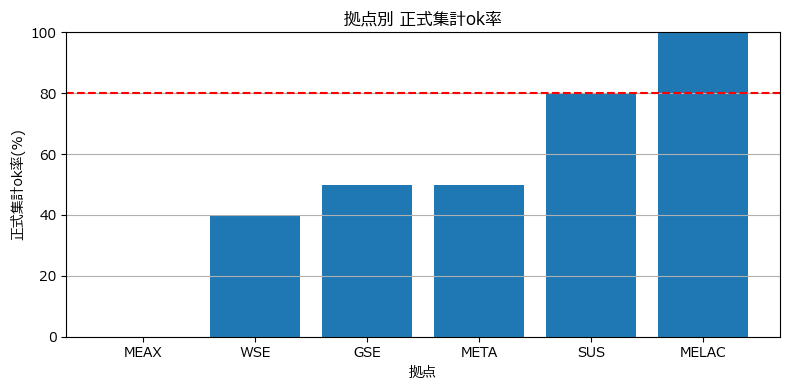

In [170]:
#cell 27
plt.figure(figsize=(8, 4))

plt.bar(
    df_site_ok_rate["site"],
    df_site_ok_rate["official_ok_rate"],
)

plt.axhline(
    y=80,
    color="red",
    linestyle="--",
)

plt.title("拠点別 正式集計ok率")
plt.xlabel("拠点")
plt.ylabel("正式集計ok率(%)")
plt.ylim(0, 100)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

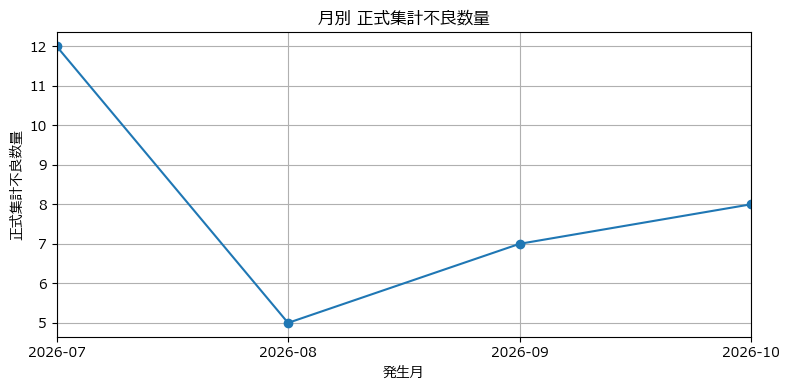

In [172]:
plt.figure(figsize=(8, 4))

plt.plot(
    df_month_official_qty["occ_month"],
    df_month_official_qty["official_defect_qty"],
    marker="o",
)

plt.xlim(
    df_month_official_qty["occ_month"].iloc[0],
    df_month_official_qty["occ_month"].iloc[-1],
)

plt.title("月別 正式集計不良数量")
plt.xlabel("発生月")
plt.ylabel("正式集計不良数量")
plt.grid(True)
plt.tight_layout()
plt.show()